In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler

In [2]:
df=pd.read_csv("development.csv")

In [3]:
df.shape

(5546, 28)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
catcher_id,5546.0,4766.986116,2.432980e+03,92.0,2772.25,4791.5,6914.75,9.445000e+03
jobma_catcher_status,5546.0,0.911828,2.835699e-01,0.0,1.00,1.0,1.00,1.000000e+00
jobma_catcher_type,5546.0,0.892715,3.095026e-01,0.0,1.00,1.0,1.00,1.000000e+00
subscription_status,5546.0,1.888388,3.149168e-01,1.0,2.00,2.0,2.00,2.000000e+00
subscription_type,5546.0,0.001082,3.287682e-02,0.0,0.00,0.0,0.00,1.000000e+00
referral_credit,5546.0,0.001442,3.795603e-02,0.0,0.00,0.0,0.00,1.000000e+00
is_premium,5546.0,0.378471,4.850496e-01,0.0,0.00,0.0,1.00,1.000000e+00
sub_user,5546.0,255.074829,4.278362e+02,0.0,1.00,5.0,108.50,1.000000e+03
per_sub_user,5546.0,2258.584565,4.165957e+03,0.0,100.00,100.0,100.00,1.200000e+04
number_of_logins,5546.0,1.020916,2.400683e-01,0.0,1.00,1.0,1.00,5.000000e+00


In [5]:
df.describe(include='all')

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,company_size,per_sub_user,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
count,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546,5546.000000,...,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000,5546.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1-25,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2707,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4766.986116,0.911828,0.892715,1.888388,0.001082,0.001442,0.378471,255.074829,NaN,2258.584565,...,0.437793,3.477101,0.903354,1.514245,8.706816,6.559502,3.346195,0.169672,0.009016,0.013343
std,2432.980364,0.283570,0.309503,0.314917,0.032877,0.037956,0.485050,427.836159,NaN,4165.956896,...,0.496160,1.297816,8.057080,18.593004,102.409681,239.932744,37.013656,3.273230,0.454126,0.902557
min,92.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2772.250000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,1.000000,NaN,100.000000,...,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4791.500000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,5.000000,NaN,100.000000,...,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6914.750000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,108.500000,NaN,100.000000,...,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
df.corr(numeric_only=True)

,catcher_id,jobma_catcher_status,jobma_catcher_type,subscription_status,subscription_type,referral_credit,is_premium,sub_user,per_sub_user,number_of_logins,...,currency,premium_plan_id,pre_recorded_kit_counts,number_of_jobs_posted,number_of_invitations,number_of_pitcher_applied,pre_rec_interviews_counts,live_interviews_counts,ai_kit_counts,ai_interviews_counts
catcher_id,1.000000,0.122304,0.365412,-0.363877,-0.033321,0.040771,-0.621707,-0.375037,0.260113,0.035693,...,0.188266,0.306169,-0.001245,-0.034347,-0.008142,-0.026860,0.002054,-0.026867,-0.003537,-0.013607
jobma_catcher_status,0.122304,1.000000,0.358644,0.095768,0.010234,0.011819,-0.134954,-0.223317,0.076737,0.013849,...,0.110337,-0.032194,-0.013045,-0.004875,-0.011336,0.001001,-0.013535,0.003686,0.006174,0.004598
jobma_catcher_type,0.365412,0.358644,1.000000,-0.100672,0.011409,0.013176,-0.199186,-0.307880,0.181082,0.010789,...,0.183777,0.130146,0.028168,0.017330,0.027991,0.005527,0.014121,0.015657,0.006883,0.005125
subscription_status,-0.363877,0.095768,-0.100672,1.000000,0.011665,-0.107230,0.126651,0.022807,0.023229,-0.062148,...,0.062320,-0.044864,-0.103901,-0.050687,-0.108095,-0.012709,-0.121031,-0.060180,-0.056014,-0.041712
subscription_type,-0.033321,0.010234,0.011409,0.011665,1.000000,-0.001251,-0.003063,-0.019507,-0.004018,0.019982,...,-0.017985,-0.012099,0.009926,0.000270,0.008879,0.001364,0.011845,-0.001706,-0.000653,-0.000487
referral_credit,0.040771,0.011819,0.013176,-0.107230,-0.001251,1.000000,-0.000272,0.011332,-0.008450,-0.003312,...,0.014342,0.018976,0.312414,0.197507,0.281312,0.052013,0.300282,0.506083,0.501452,0.378470
is_premium,-0.621707,-0.134954,-0.199186,0.126651,-0.003063,-0.000272,1.000000,0.357765,-0.199428,-0.007593,...,-0.200025,-0.195219,0.067644,0.058763,0.054568,0.026884,0.063538,0.034969,0.018893,0.016063
sub_user,-0.375037,-0.223317,-0.307880,0.022807,-0.019507,0.011332,0.357765,1.000000,-0.051687,-0.005216,...,-0.305266,0.131103,0.024872,0.060028,0.003091,0.028863,0.025644,0.056796,0.018087,0.022469
per_sub_user,0.260113,0.076737,0.181082,0.023229,-0.004018,-0.008450,-0.199428,-0.051687,1.000000,-0.035905,...,0.480640,0.710208,0.055994,0.005729,0.058051,0.001055,0.062013,-0.015649,-0.009345,-0.007661
number_of_logins,0.035693,0.013849,0.010789,-0.062148,0.019982,-0.003312,-0.007593,-0.005216,-0.035905,1.000000,...,-0.043581,-0.038980,0.000020,0.001509,0.002208,-0.000247,0.007344,0.007417,-0.001730,-0.001288


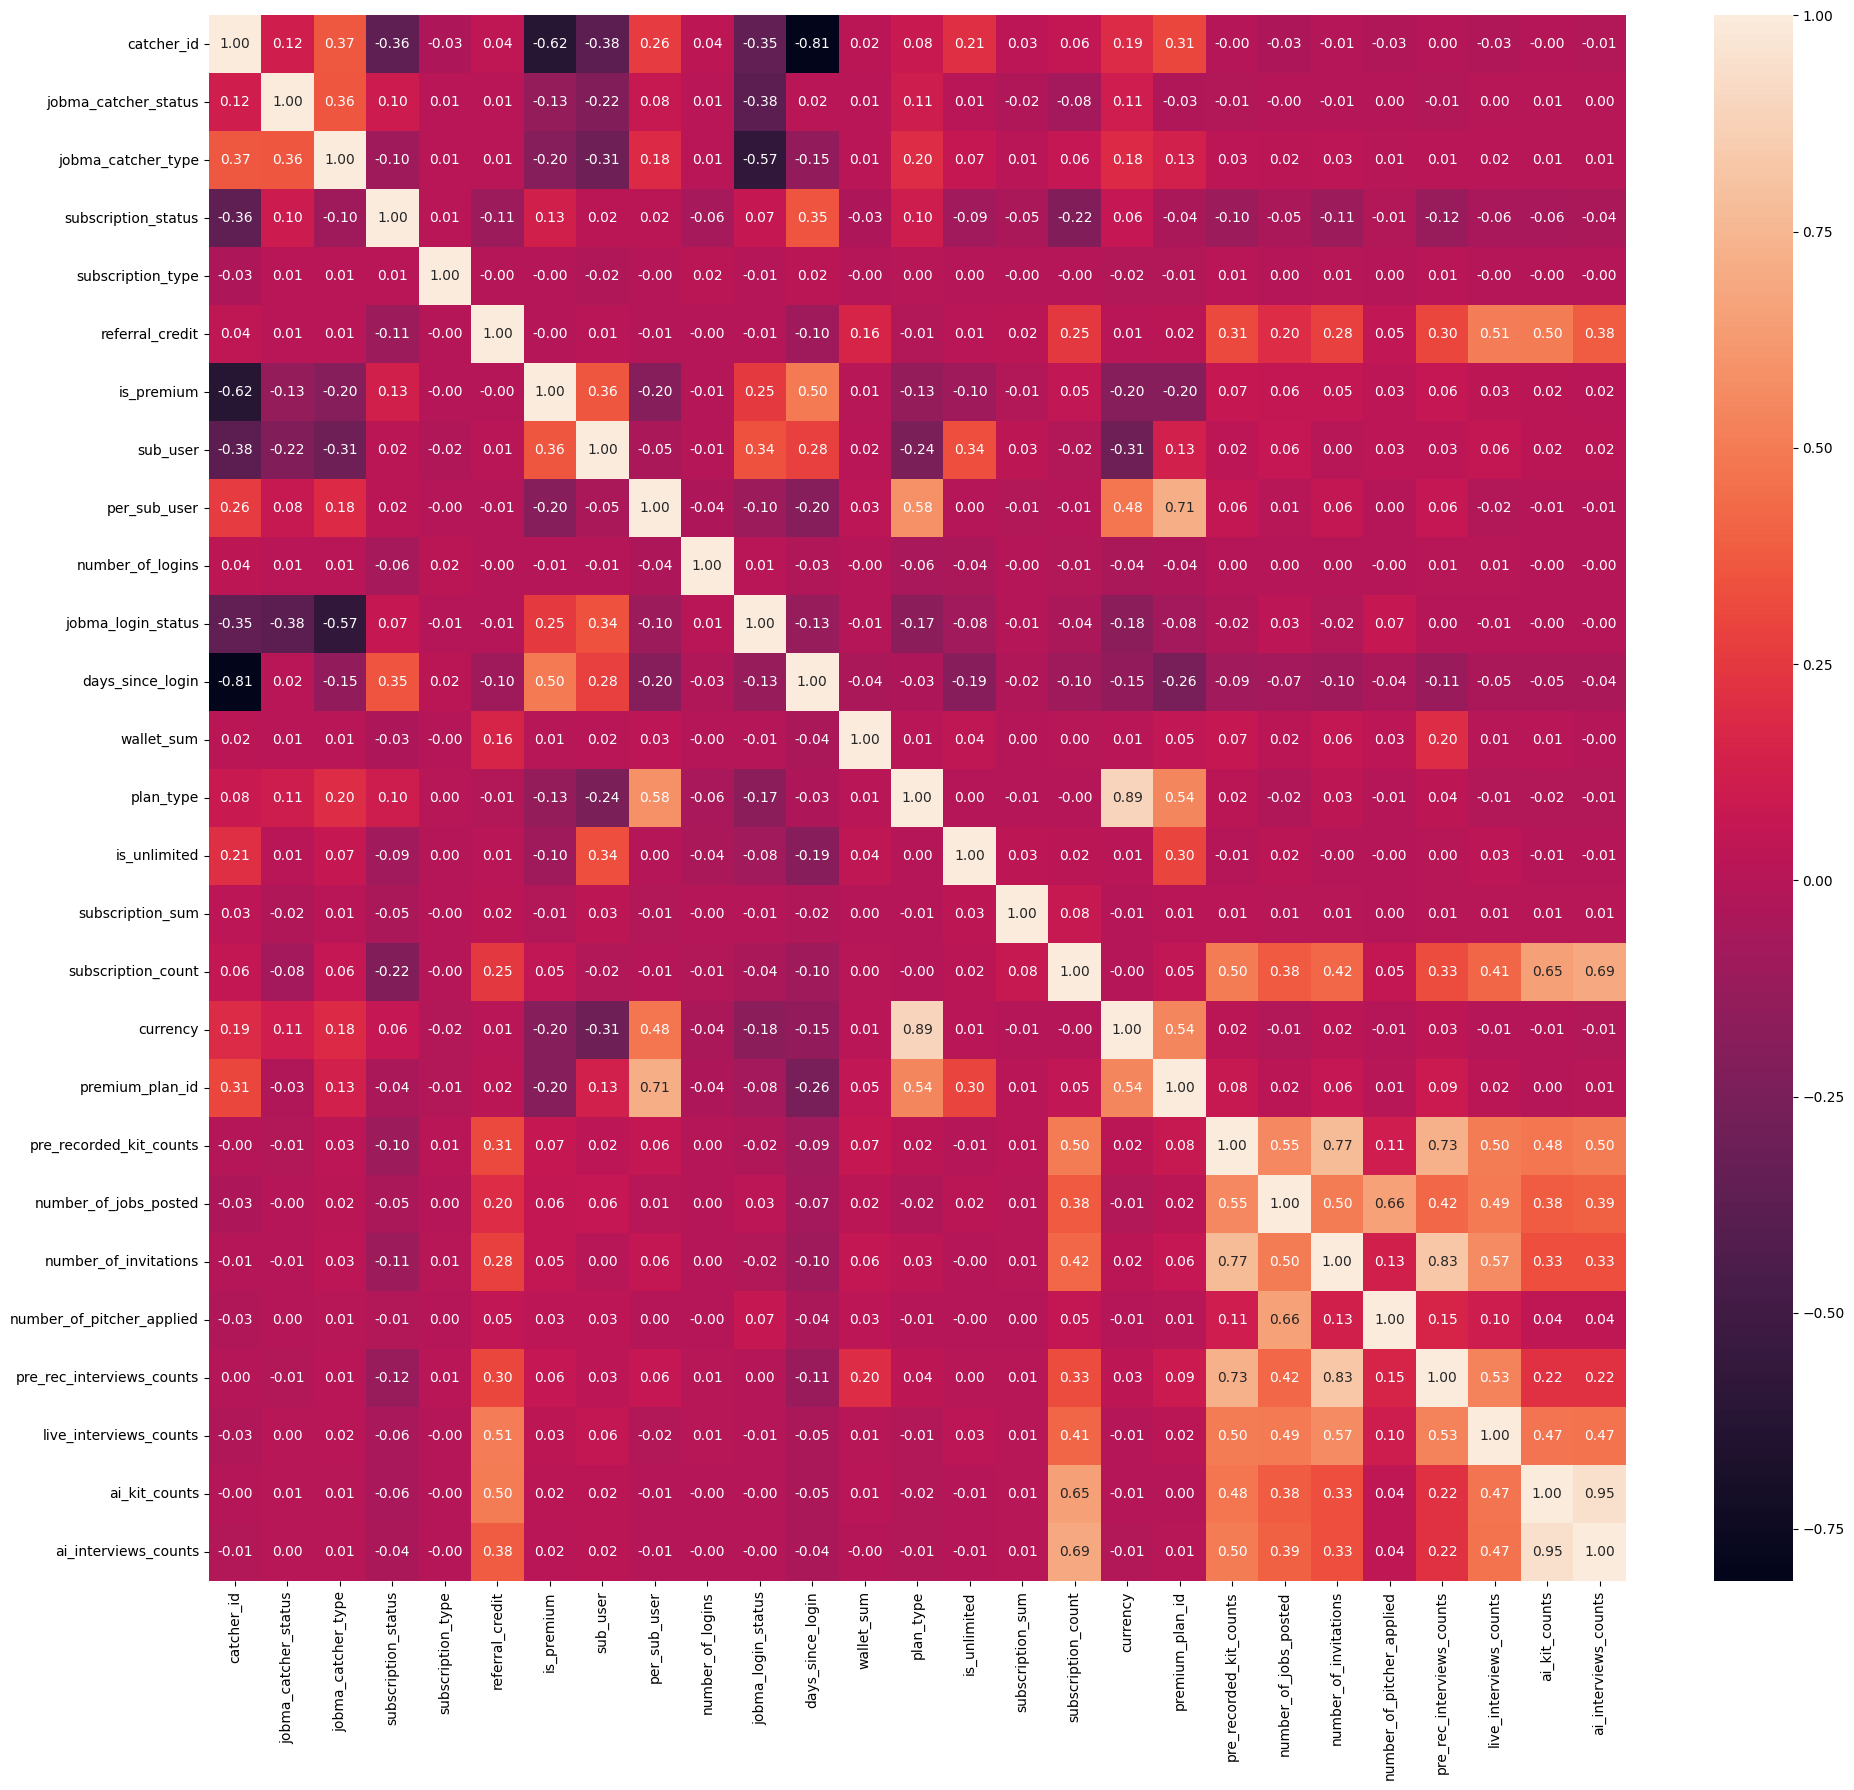

In [7]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')
plt.tight_layout()
plt.show()

# Visualising Sub_user

In [8]:
df['sub_user'].value_counts().tail(20)

sub_user
123    1
35     1
37     1
109    1
64     1
63     1
65     1
130    1
145    1
40     1
107    1
120    1
116    1
19     1
113    1
24     1
29     1
73     1
53     1
23     1
Name: count, dtype: int64

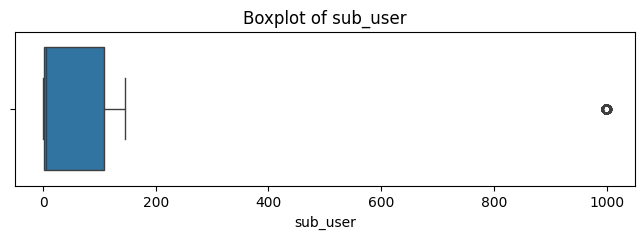

In [9]:
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['sub_user'])
plt.title('Boxplot of sub_user')
plt.show()


<Axes: xlabel='sub_user', ylabel='count'>

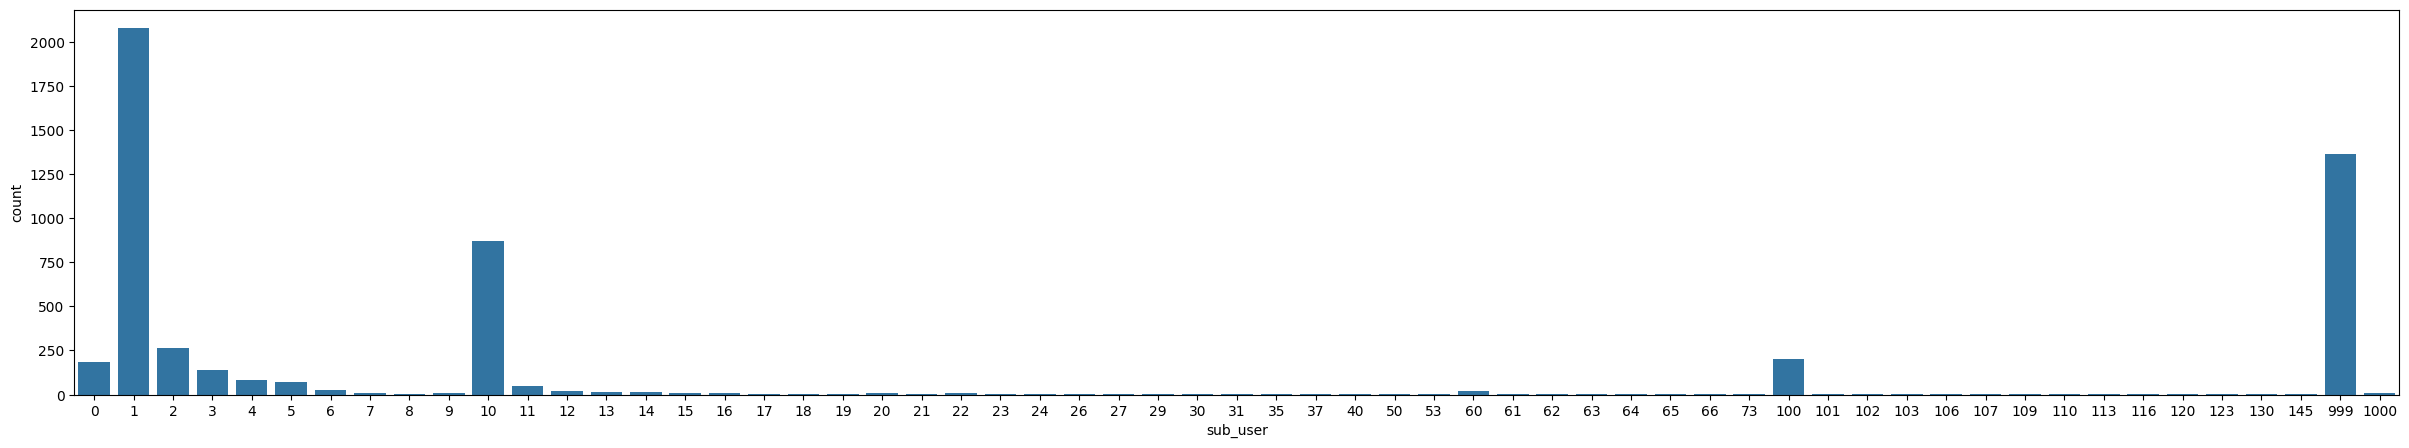

In [10]:
plt.figure(figsize=(30,5))
sns.countplot(x=df['sub_user'])

<Axes: xlabel='live_interviews_counts'>

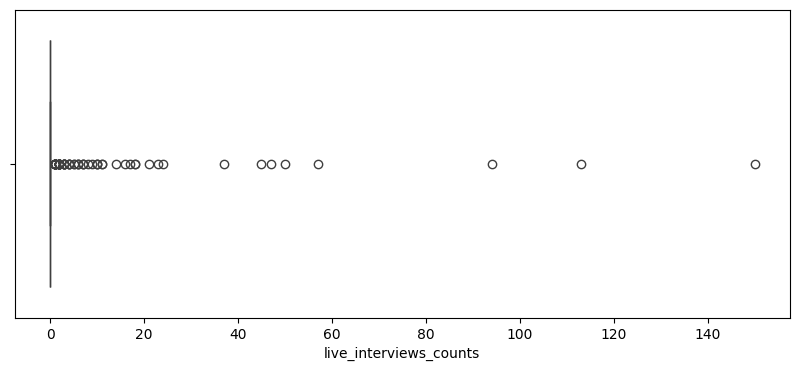

In [15]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['live_interviews_counts'])

<Axes: xlabel='live_interviews_counts', ylabel='count'>

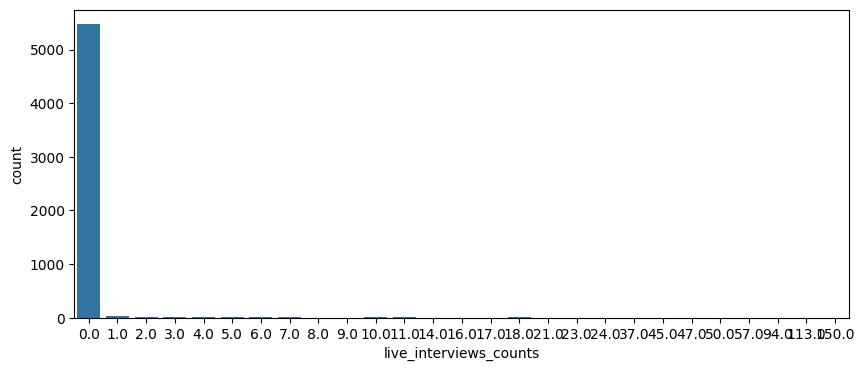

In [14]:
plt.figure(figsize=(10,4))
sns.countplot(x=df['live_interviews_counts'])

In [ ]:
#now currency_val

<Axes: xlabel='currency', ylabel='count'>

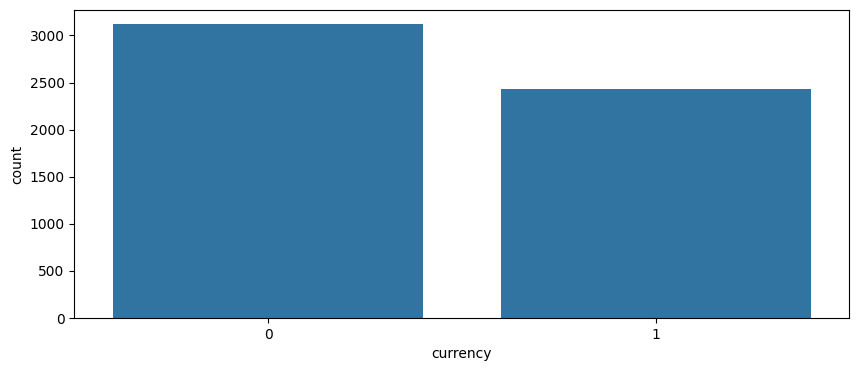

In [20]:
plt.figure(figsize=(10,4))
sns.countplot(x=df['currency'])

In [ ]:
#referral_credit

<Axes: xlabel='referral_credit'>

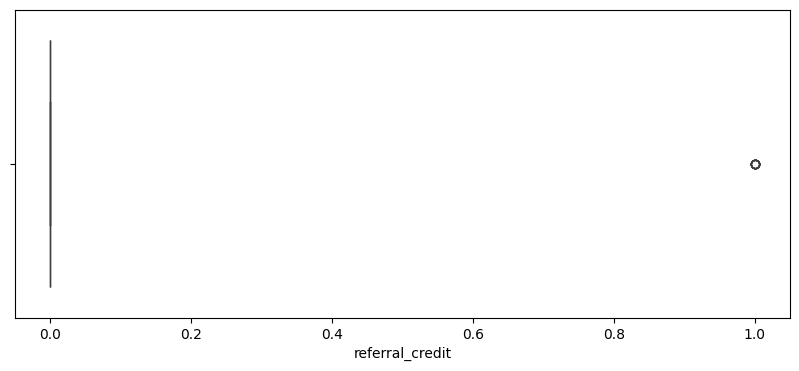

In [21]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['referral_credit'])

<Axes: xlabel='referral_credit', ylabel='count'>

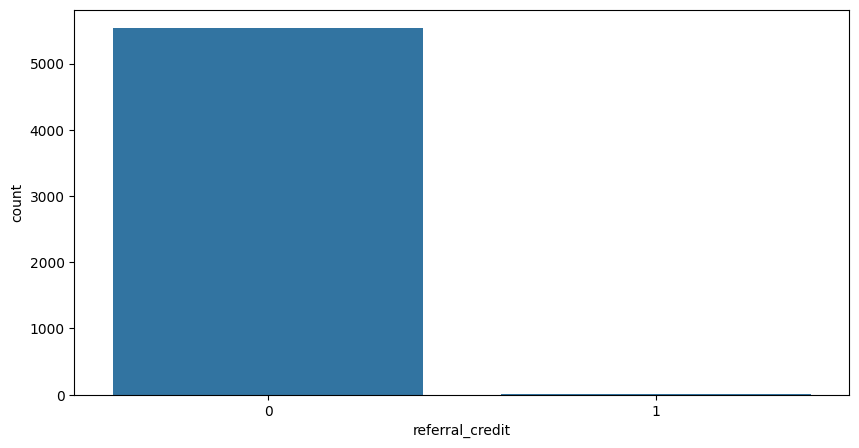

In [22]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['referral_credit'])

<Axes: xlabel='days_since_login', ylabel='Count'>

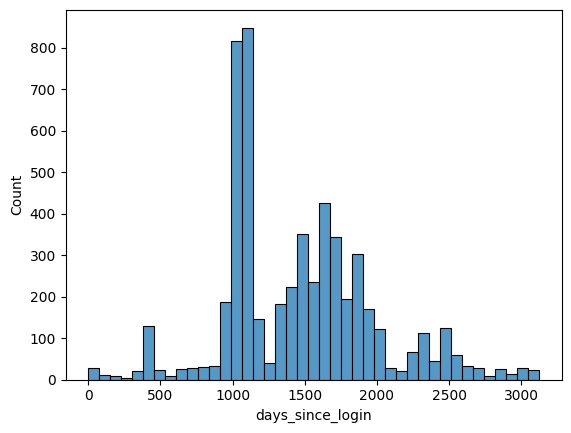

In [26]:
sns.histplot(data=df['days_since_login'])

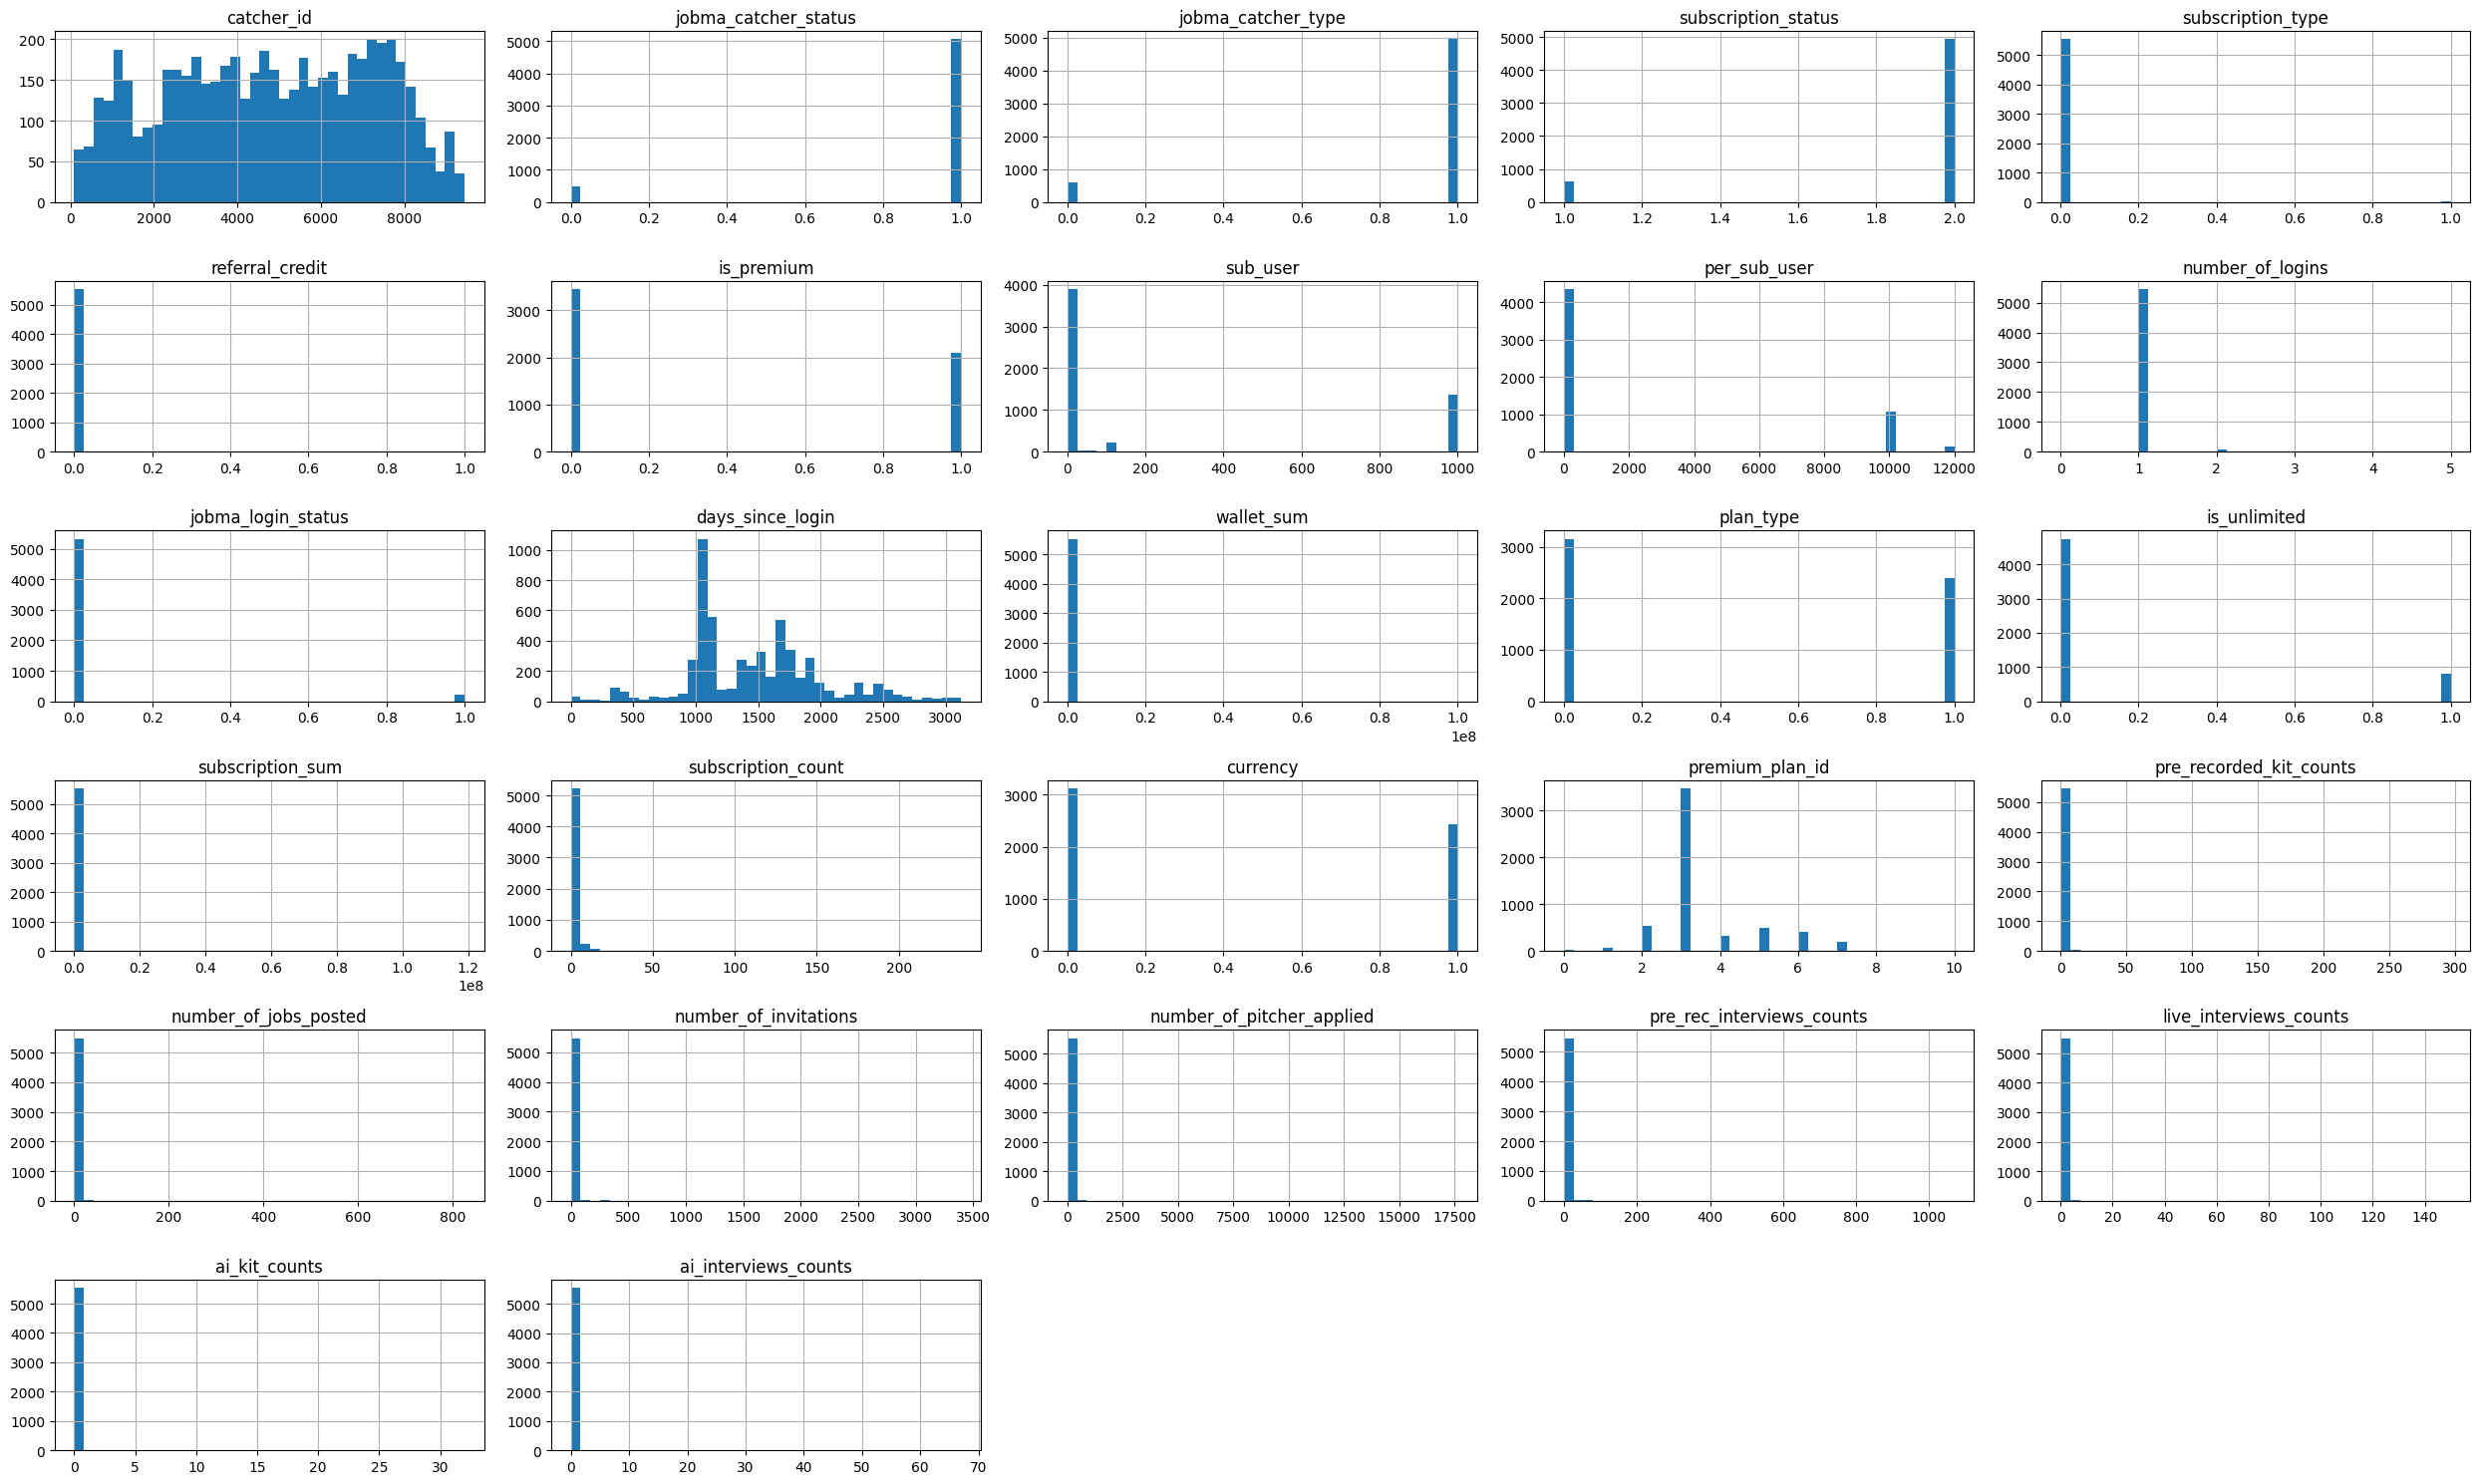

In [27]:
df.hist(bins=40, figsize=(25, 15))
plt.tight_layout()
plt.show()

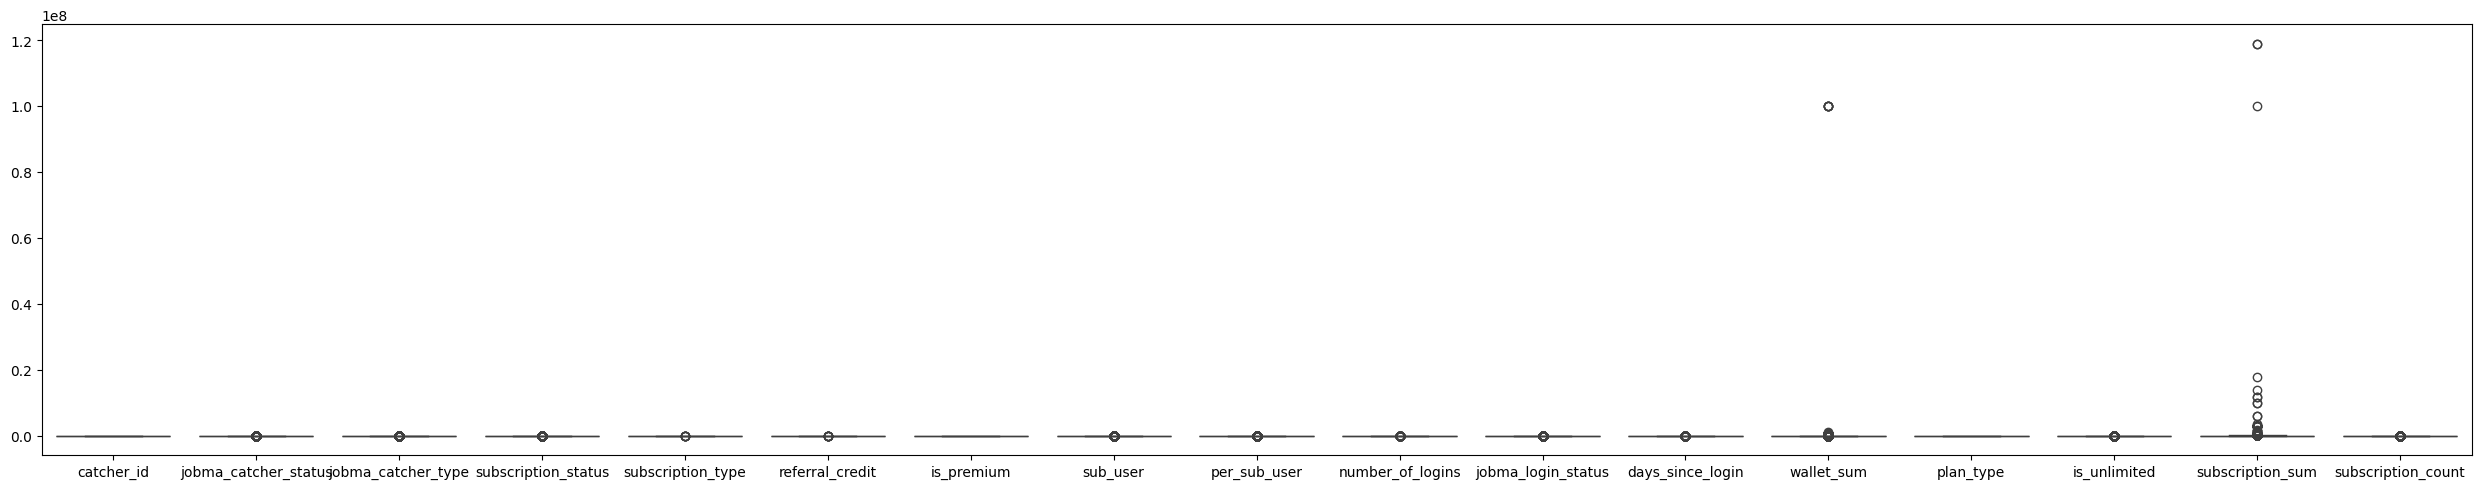

In [29]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df.iloc[:, :18])
plt.tight_layout()
plt.show()

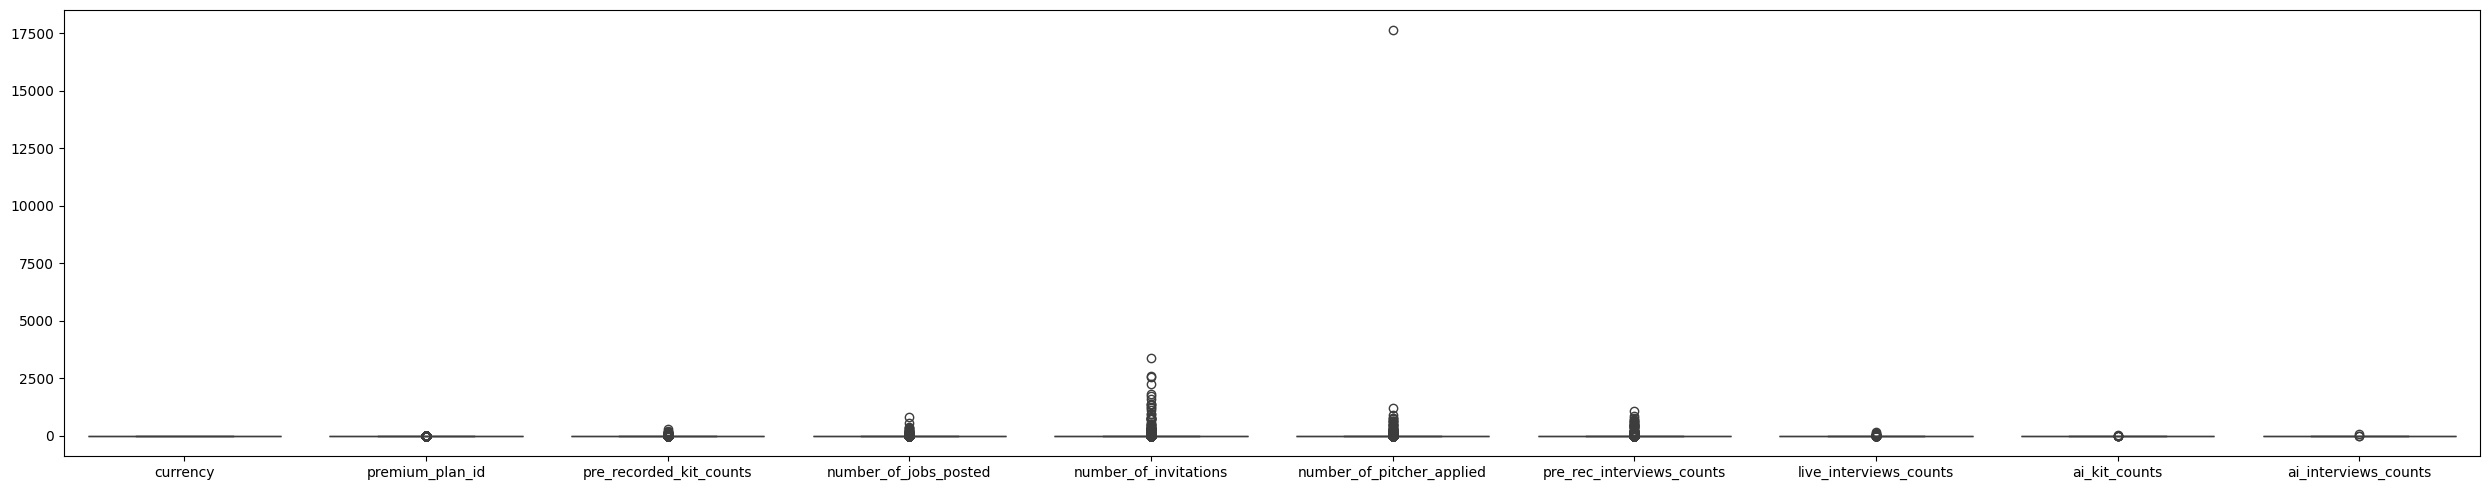

In [30]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df.iloc[:, 18:])
plt.tight_layout()
plt.show()


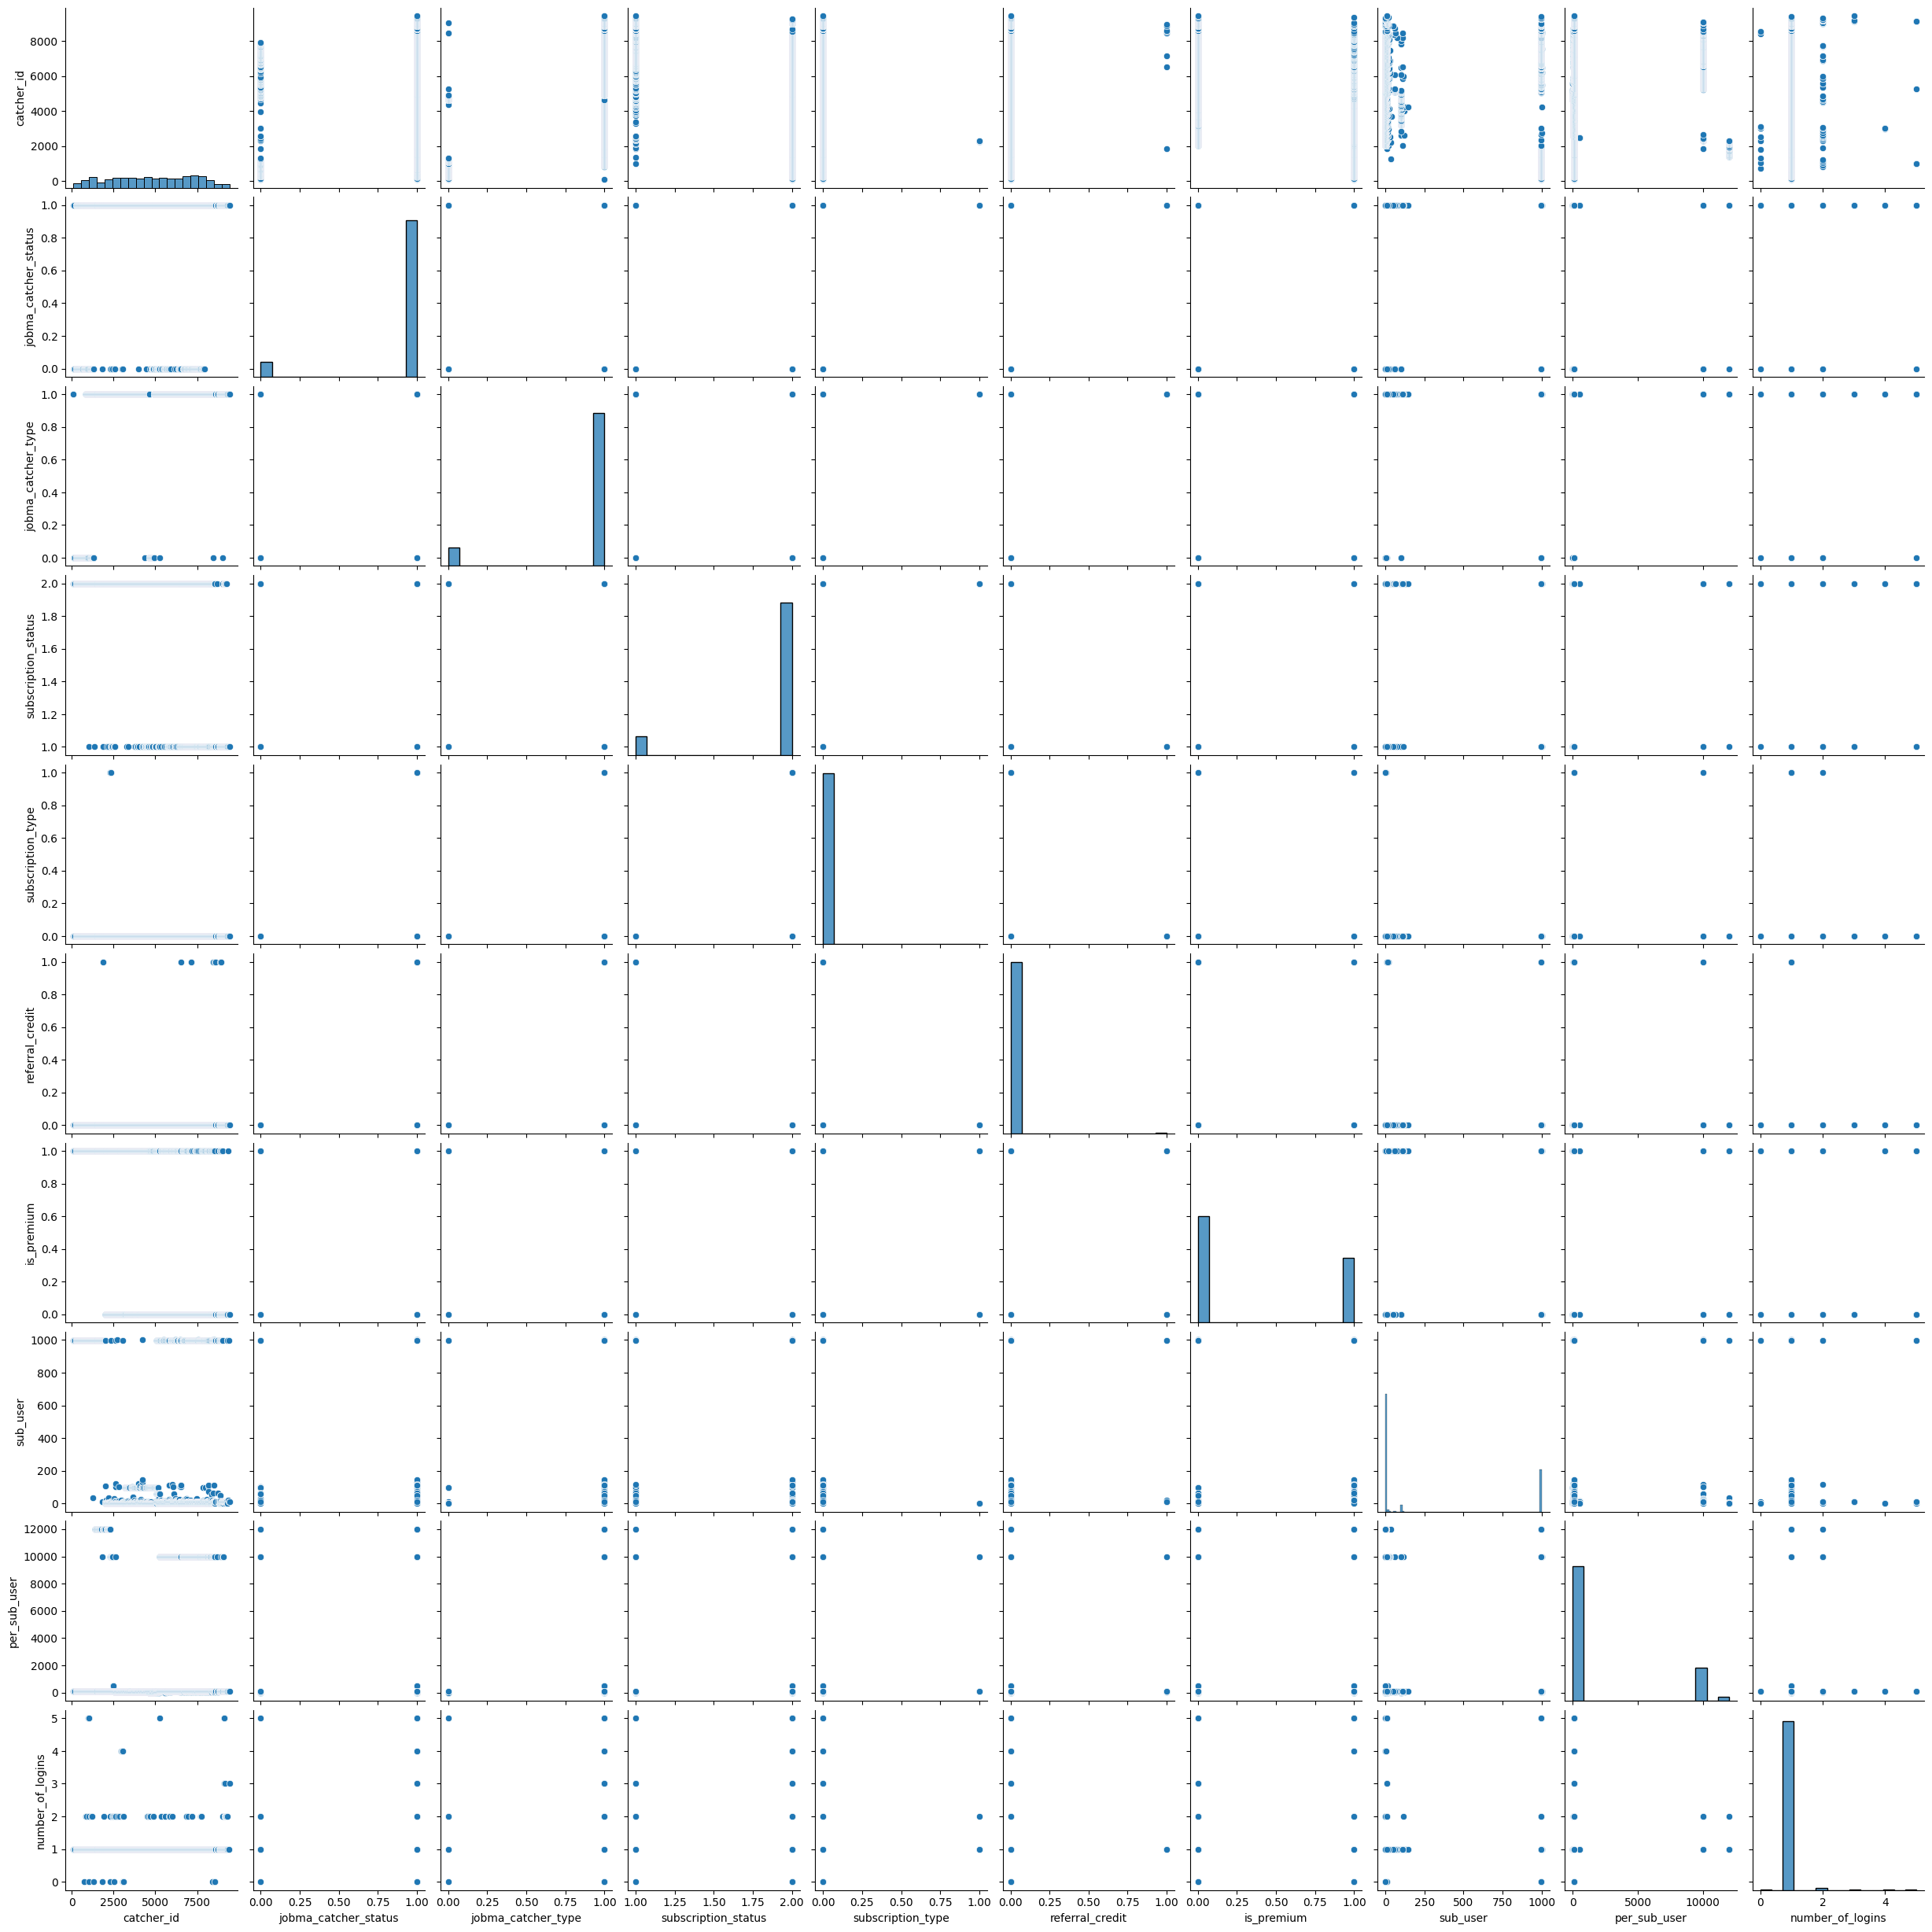

In [31]:
subset_cols = df.select_dtypes(include=['float64', 'int64']).columns[:10]
sns.pairplot(df[subset_cols], hue=None)
plt.show()

<Axes: xlabel='jobma_catcher_status', ylabel='count'>

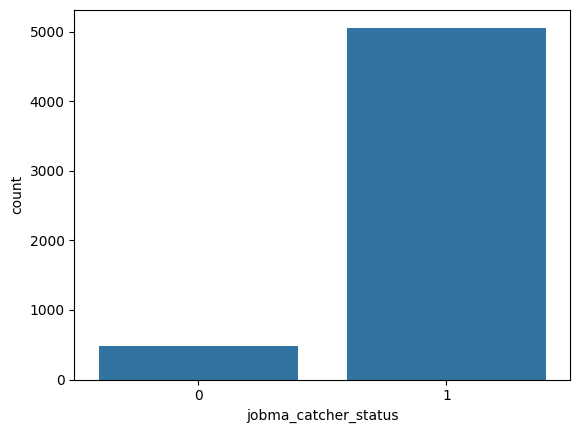

In [32]:
sns.countplot(x=df['jobma_catcher_status'])

<Axes: xlabel='subscription_status', ylabel='count'>

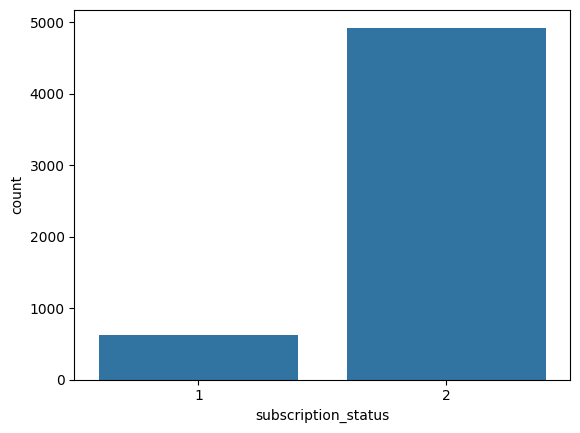

In [35]:
sns.countplot(x=df['subscription_status'])

<Axes: xlabel='company_size', ylabel='count'>

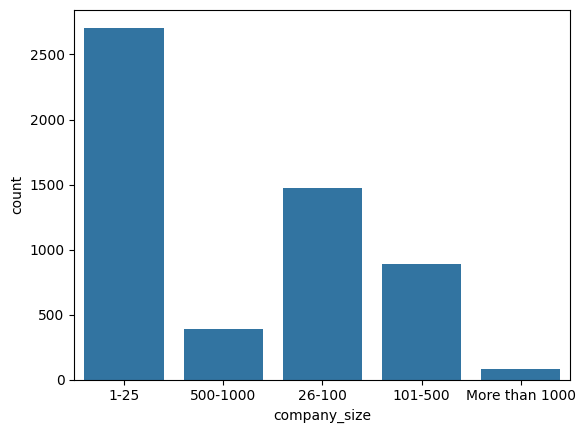

In [36]:
sns.countplot(x=df['company_size'])

<Axes: xlabel='plan_type', ylabel='count'>

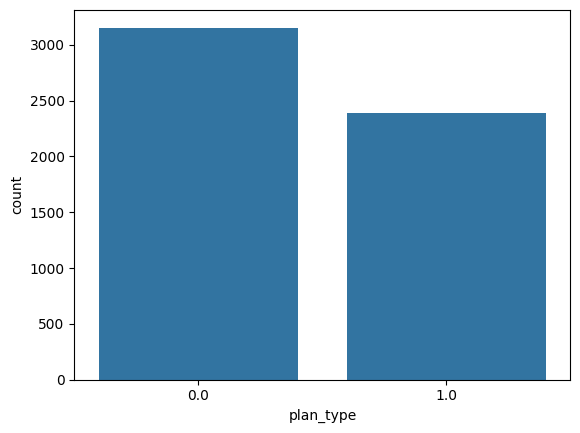

In [37]:
sns.countplot(x=df['plan_type'])

<Axes: xlabel='is_unlimited', ylabel='count'>

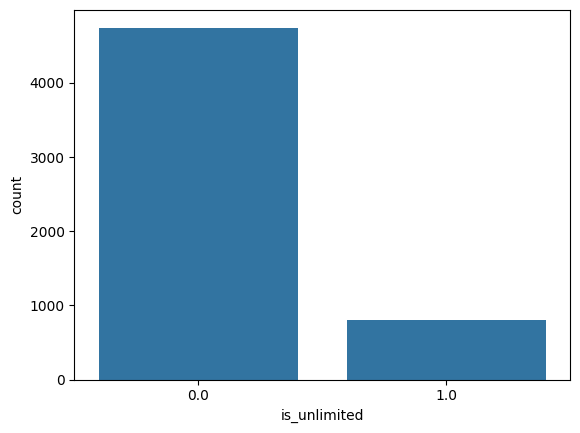

In [38]:
sns.countplot(x=df['is_unlimited'])

<Axes: xlabel='wallet_sum', ylabel='Count'>

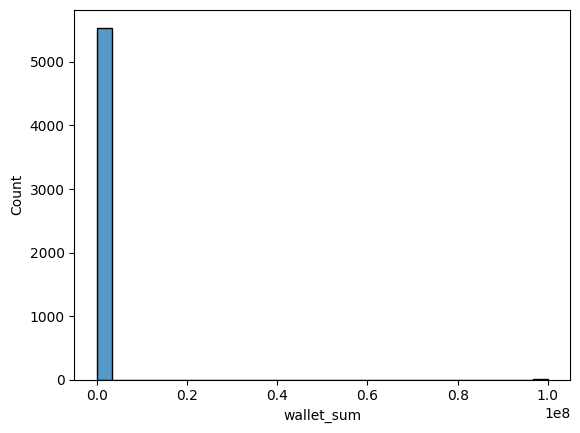

In [42]:
sns.histplot(df['wallet_sum'], bins=30)

<Axes: xlabel='subscription_sum', ylabel='Count'>

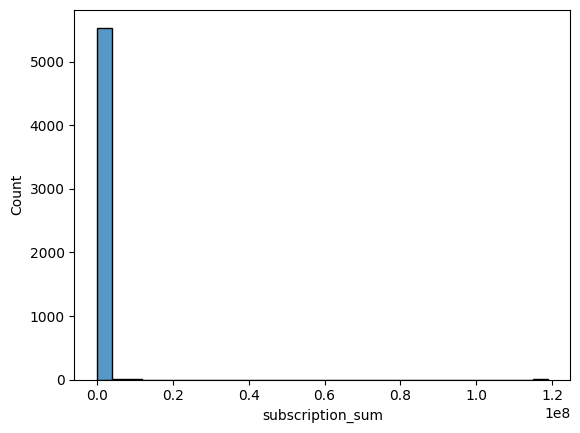

In [44]:
sns.histplot(df['subscription_sum'], bins=30)

<Axes: xlabel='days_since_login', ylabel='Count'>

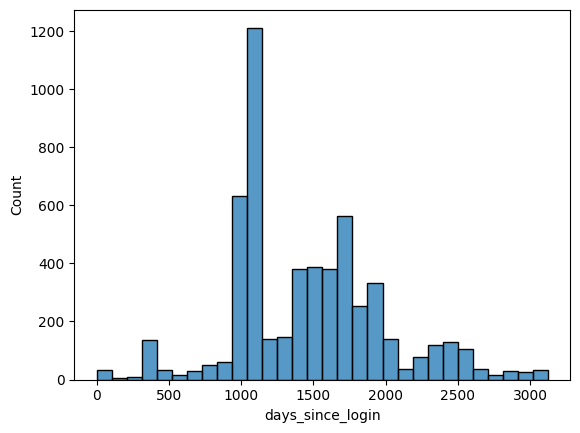

In [47]:
sns.histplot(df['days_since_login'], bins=30)

<Axes: xlabel='number_of_invitations', ylabel='Count'>

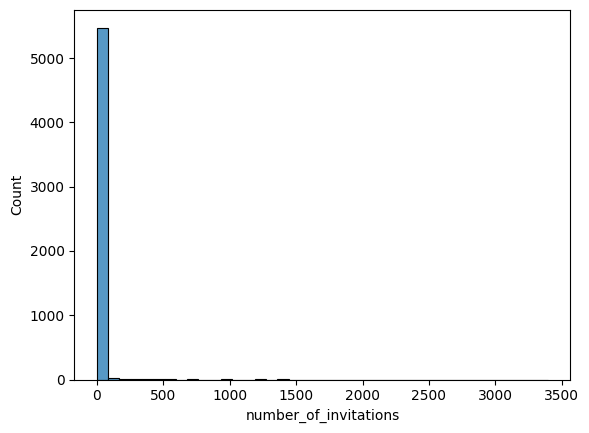

In [52]:
sns.histplot(df['number_of_invitations'], bins=40)

<Axes: xlabel='number_of_logins', ylabel='Count'>

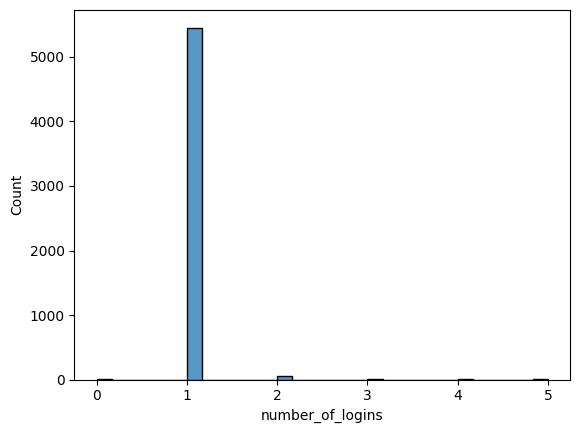

In [53]:
sns.histplot(df['number_of_logins'], bins=30)

In [55]:
df.columns

Index(['catcher_id', 'jobma_catcher_status', 'jobma_catcher_type',
       'subscription_status', 'subscription_type', 'referral_credit',
       'is_premium', 'sub_user', 'company_size', 'per_sub_user',
       'number_of_logins', 'jobma_login_status', 'days_since_login',
       'wallet_sum', 'plan_type', 'is_unlimited', 'subscription_sum',
       'subscription_count', 'currency', 'premium_plan_id',
       'pre_recorded_kit_counts', 'number_of_jobs_posted',
       'number_of_invitations', 'number_of_pitcher_applied',
       'pre_rec_interviews_counts', 'live_interviews_counts', 'ai_kit_counts',
       'ai_interviews_counts'],
      dtype='object')

<Axes: xlabel='pre_recorded_kit_counts', ylabel='Count'>

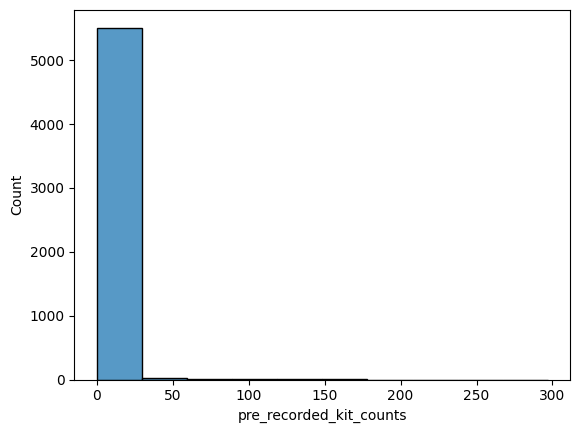

In [56]:
sns.histplot(df['pre_recorded_kit_counts'], bins=10)

<Axes: xlabel='number_of_jobs_posted', ylabel='Count'>

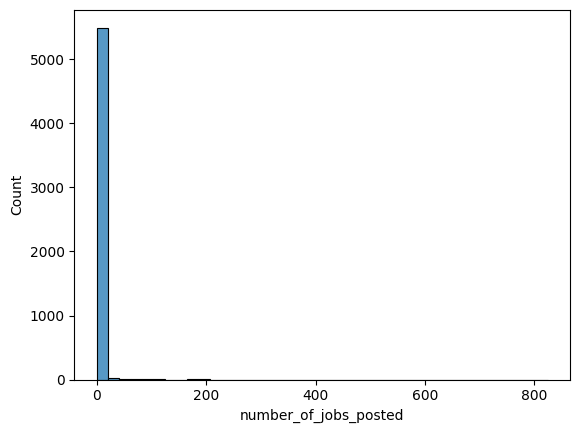

In [57]:
sns.histplot(df['number_of_jobs_posted'], bins=40)

<Axes: xlabel='company_size', ylabel='wallet_sum'>

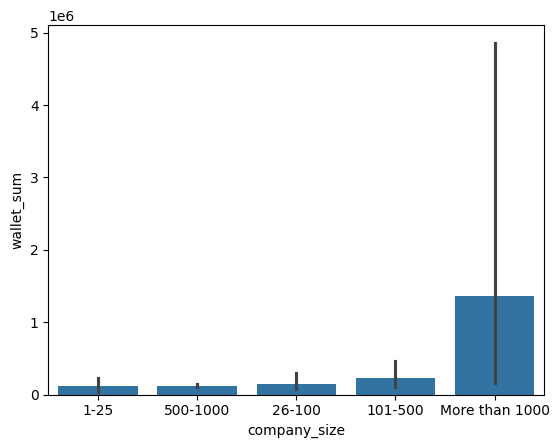

In [60]:
sns.barplot(x='company_size', y='wallet_sum', data=df) #lot of whisker and outliers here

<Axes: xlabel='company_size', ylabel='subscription_sum'>

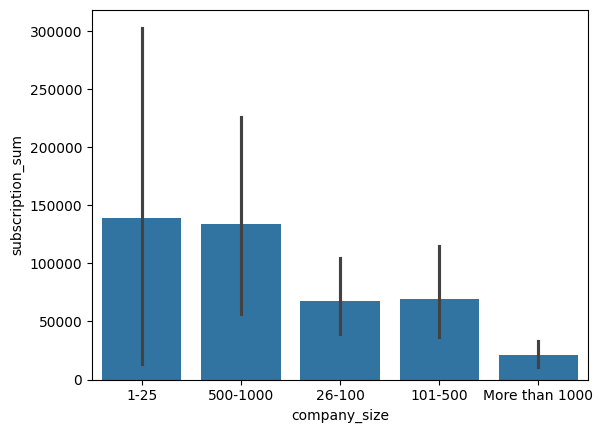

In [61]:
sns.barplot(x='company_size', y='subscription_sum', data=df)

<Axes: xlabel='subscription_sum', ylabel='plan_type'>

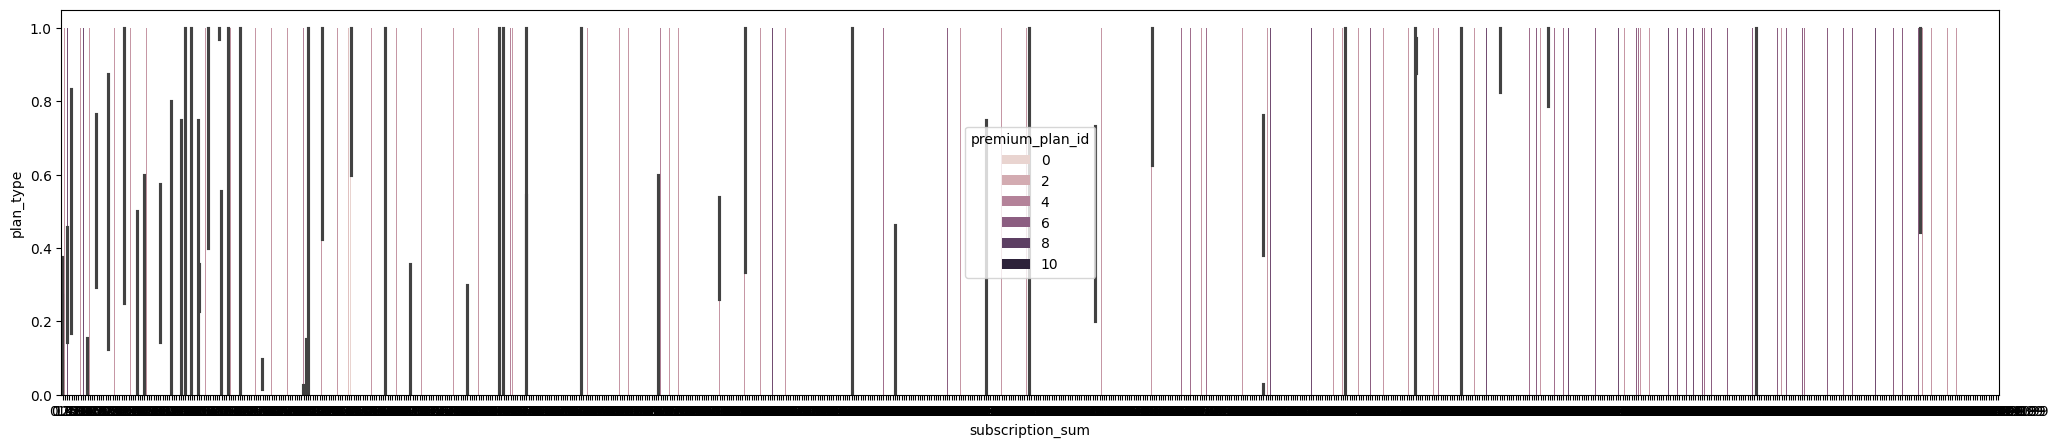

In [65]:
plt.figure(figsize=(25, 5))
sns.barplot(x='subscription_sum', y='plan_type', hue='premium_plan_id', data=df)

<Axes: xlabel='subscription_bin', ylabel='is_premium'>

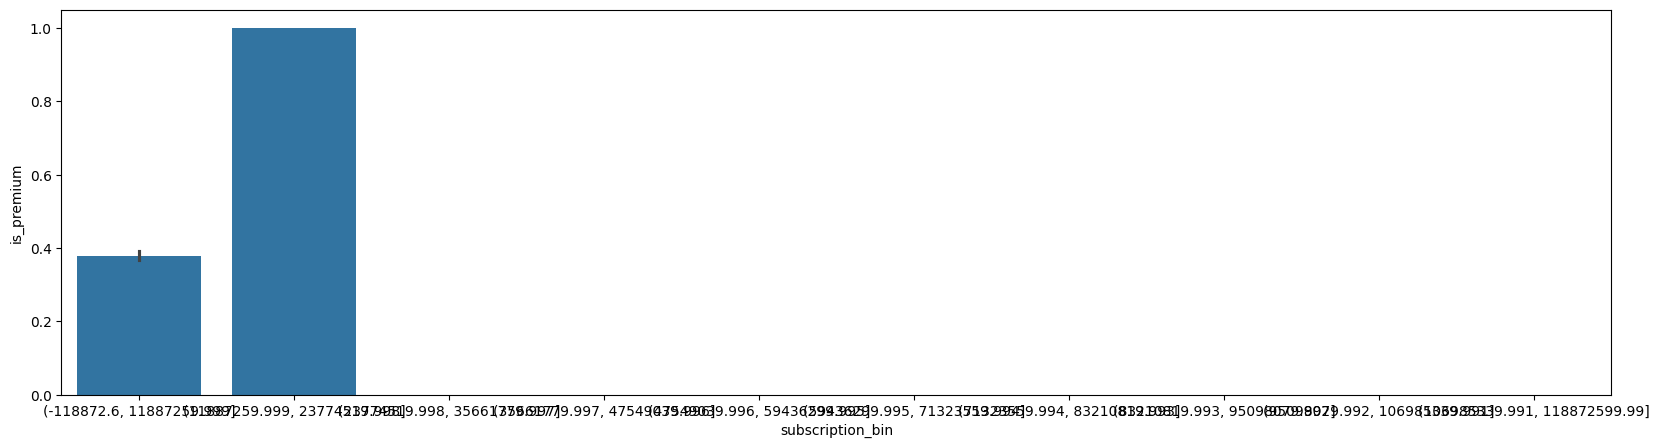

In [66]:
df['subscription_bin'] = pd.cut(df['subscription_sum'], bins=10)
plt.figure(figsize=(20,5))
sns.barplot(x='subscription_bin', y='is_premium', data=df)

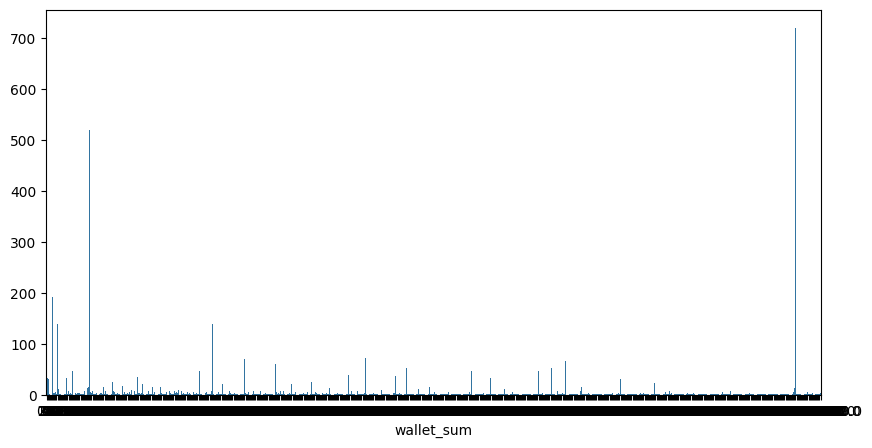

In [68]:
wallet_counts = df['wallet_sum'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.barplot(x=wallet_counts.index, y=wallet_counts.values)
plt.show()

<Axes: >

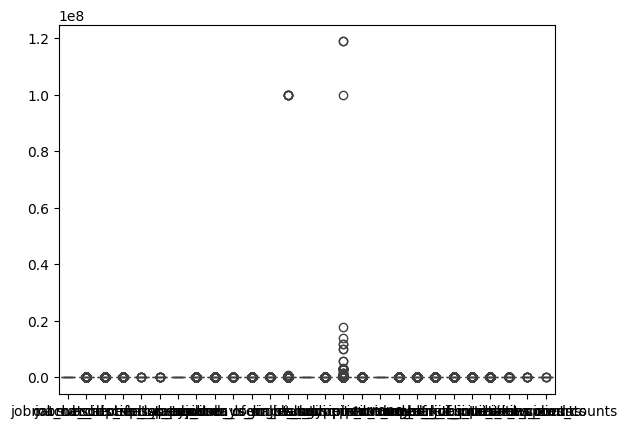

In [69]:
sns.boxplot(df)

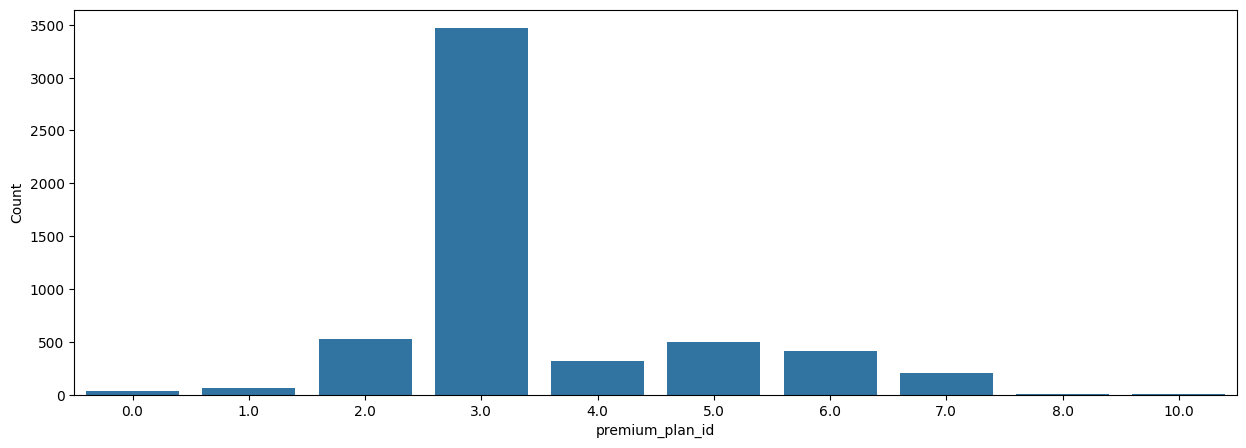

In [72]:
plt.figure(figsize=(15,5))
sns.countplot(x='premium_plan_id', data=df)
plt.ylabel('Count')
plt.show()

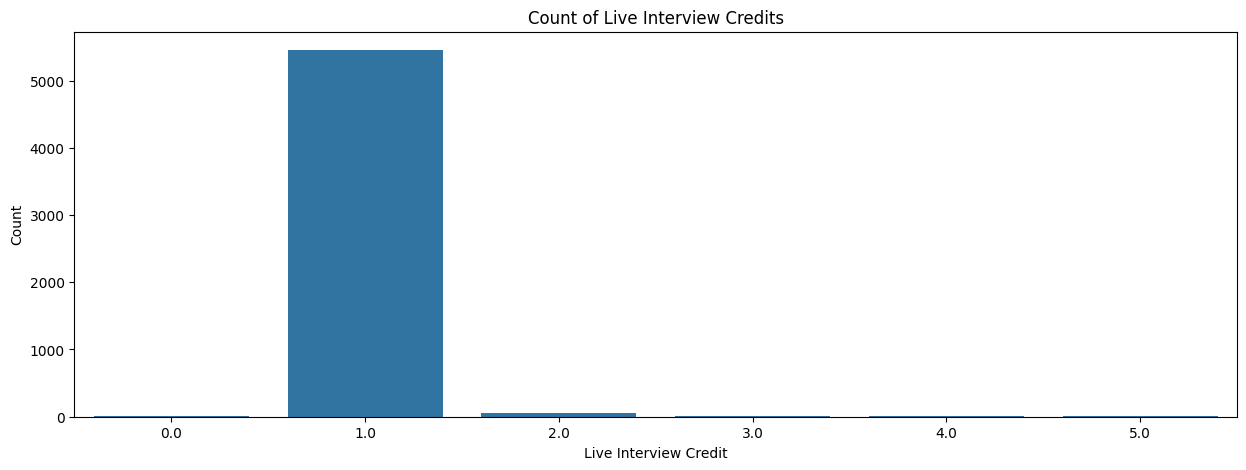

In [73]:
plt.figure(figsize=(15,5))
sns.countplot(x='number_of_logins', data=df)
plt.title('Count of Live Interview Credits')
plt.xlabel('Live Interview Credit')
plt.ylabel('Count')
plt.show()

# Boxplot for checking the extreme outliers

<Axes: >

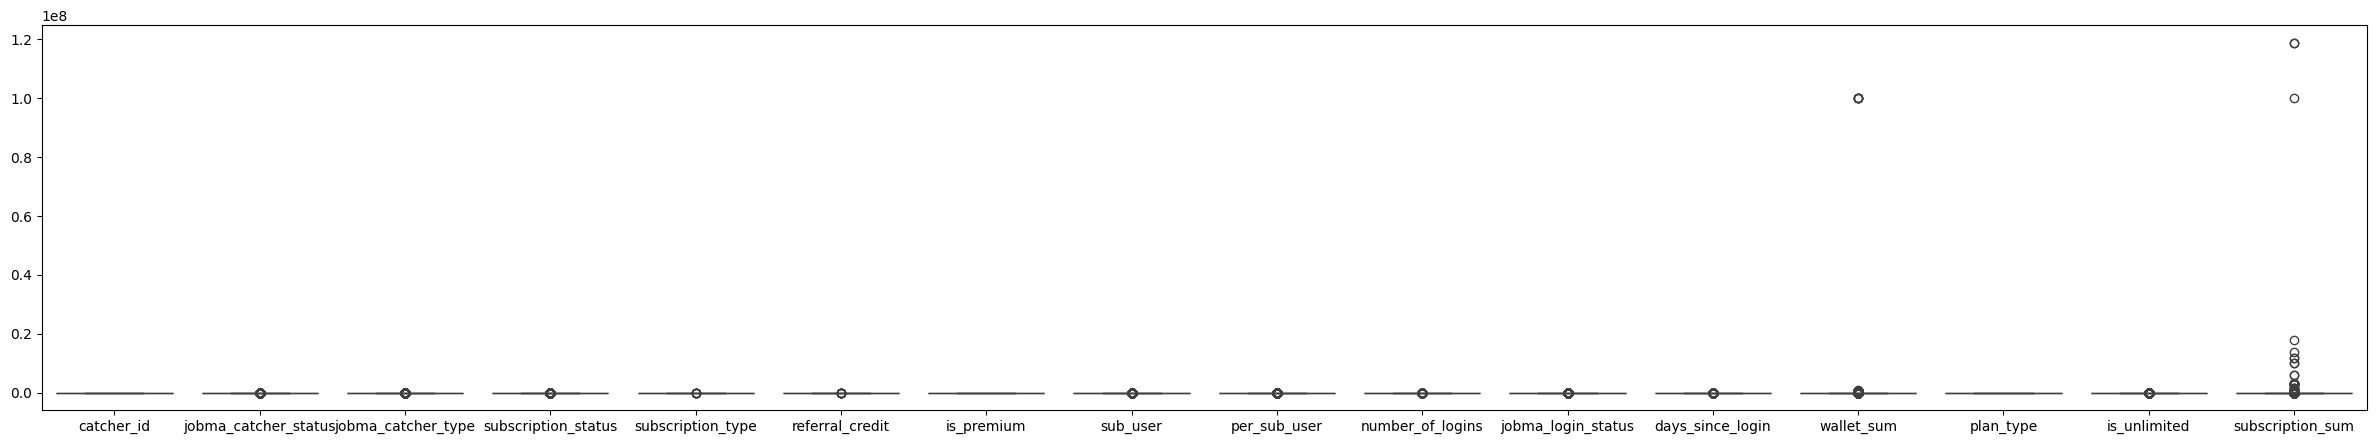

In [74]:
plt.figure(figsize=(30,5))
sns.boxplot(df.iloc[:, :17])

<Axes: >

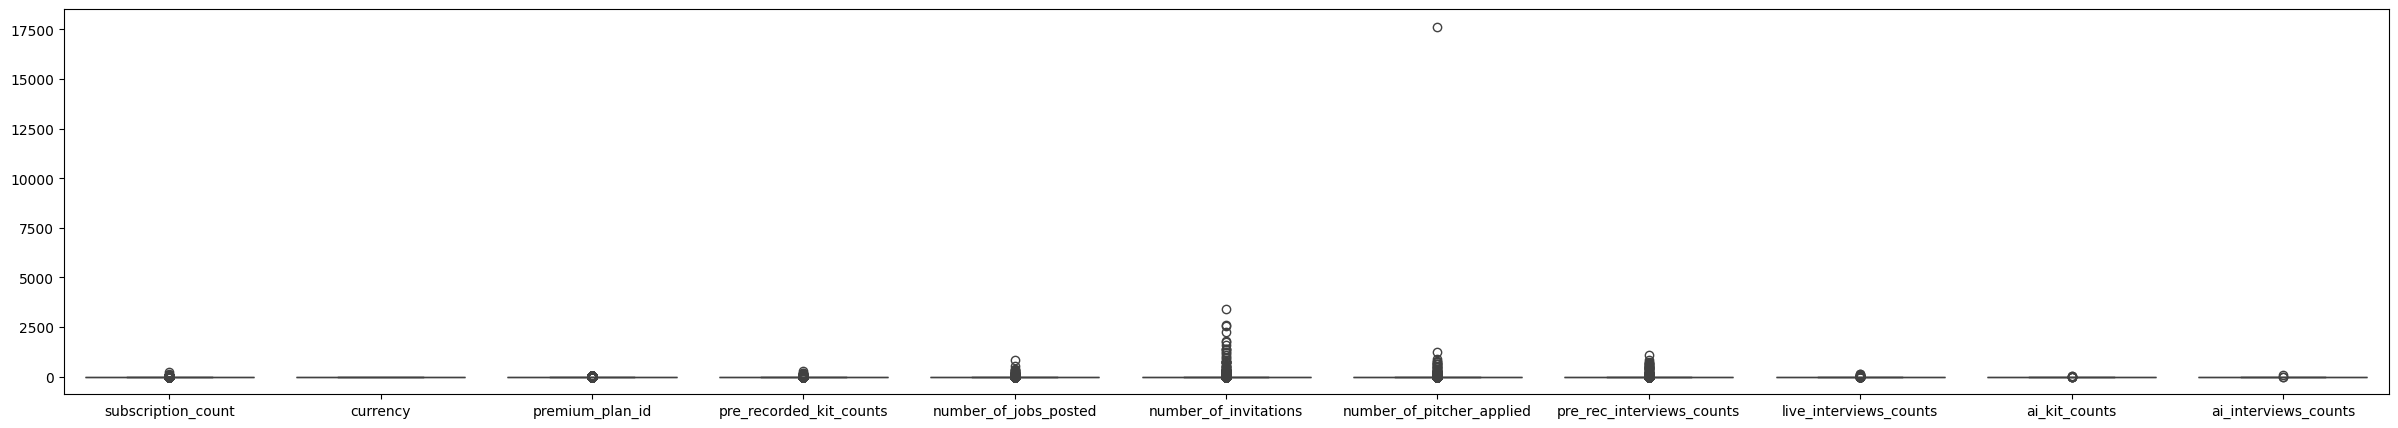

In [75]:
plt.figure(figsize=(30,5))
sns.boxplot(df.iloc[:, 17:])

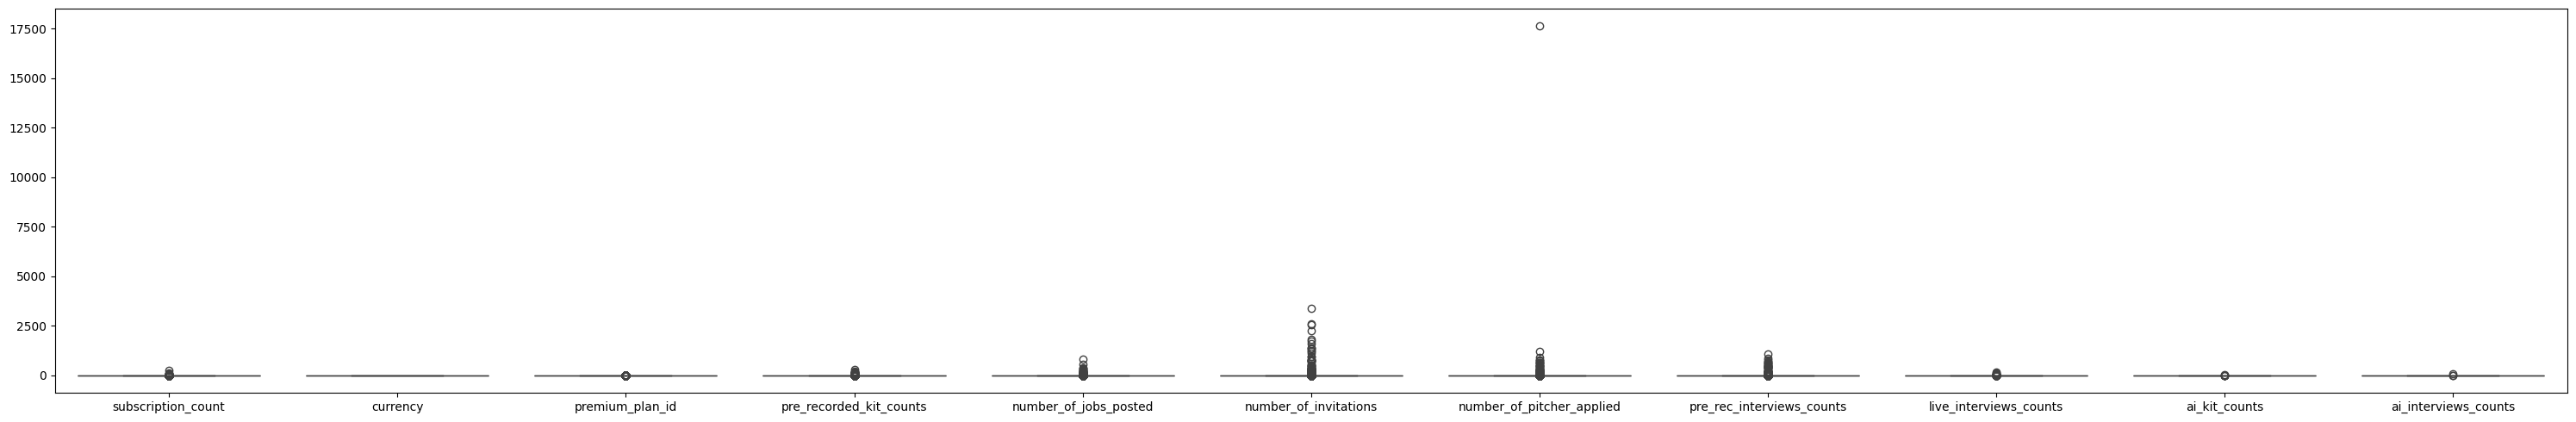

In [76]:
plt.figure(figsize=(30, 5))
sns.boxplot(df.iloc[:, 17:])
plt.tight_layout()
plt.show()